In [25]:
# ==============================================================================
# ENSEMBLE CREDIT RISK ASSESSMENT: ML + ACO + ANFIS + QP BENCHMARK
#
# ARCHITECTURAL NOTE — ANFIS:
# The ANFIS component implements Option A (Confidence Calibration). Rather than
# causing rule explosion via 20 raw features, it takes the ACO-optimized
# continuous probability as a univariate input and acts as a non-linear
# neuro-fuzzy calibrator mapping statistical confidence to linguistic rules.
#
# ARCHITECTURAL NOTE — ACO SIMPLEX MAPPING:
# Unconstrained ACO coordinates are mapped to the probability simplex via
# softmax. This guarantees differentiability and sum-to-one, but cannot
# produce weights of exactly 0.0 or 1.0 (only asymptotic approach).
# For this 3-model ensemble the approximation error is negligible. If exact
# sparsity (hard model elimination) were required, Euclidean projection onto
# the unit simplex would be the correct replacement.
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.optimize import minimize
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
#from sklearn.preprocessing import OneHotEncoder

#from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.base import clone
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             precision_recall_curve)

In [26]:
# ==============================================================================
# [Block 1] Data Ingestion & Splitting
# ==============================================================================
print("--- BLOCK 1: DATA INGESTION & STRICT SPLITTING ---")
data = fetch_openml(name='credit-g', version=1, as_frame=True, parser='auto')
X = data.data
y = data.target.map({'good': 0, 'bad': 1}).values.astype(int)

# Strict 80/20 split. No preprocessing here — prevents any form of leakage.
X_train, X_test, y_train_array, y_test_array = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Data securely partitioned. Train: {X_train.shape}, Test: {X_test.shape}")

--- BLOCK 1: DATA INGESTION & STRICT SPLITTING ---
Data securely partitioned. Train: (800, 20), Test: (200, 20)


In [27]:
# ==============================================================================
# [Block 2] Leakage-Free OOF Generation via 3-Stage Mixed-Data Synthesis
#
# ARCHITECTURAL NOTE — ENSEMBLE INDUCTIVE BIAS:
# The transition from Logistic Regression to Random Forest alters the ensemble's
# diversity. The previous ensemble (LR/SVM/MLP) spanned Linear, Margin, and Deep
# priors. The current ensemble (RF/SVM/MLP) is heavily biased toward high-capacity,
# non-linear boundaries. While slightly reducing theoretical diversity, the RF
# provides superior robustness to the mixed-type tabular topology.
#
# ARCHITECTURAL NOTE — SMOTENC DISTANCE CONCENTRATION:
# Post-OHE, the feature space expands to ~48 dimensions. In high-dimensional spaces,
# Euclidean distances concentrate, reducing the geometric fidelity of the k-NN
# algorithm inside SMOTENC. This is an acknowledged mathematical limitation of
# applying synthetic interpolation to heavily encoded datasets.
# ==============================================================================

print("\n--- BLOCK 2: BASE MODELS & OUT-OF-FOLD PREDICTIONS ---")

numerical_cols   = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['category', 'object']).columns.tolist()

# ------------------------------------------------------------------------------
# STAGE 1: SPATIAL CONDITIONING (ROBUST STATISTICS)
# ------------------------------------------------------------------------------
prep_stage_1 = ColumnTransformer(transformers=[
    ('num', RobustScaler(), numerical_cols),
    ('cat', 'passthrough', categorical_cols)
])

cat_indices = list(range(len(numerical_cols), len(numerical_cols) + len(categorical_cols)))

# ------------------------------------------------------------------------------
# STAGE 2 & 3: SYNTHESIS AND ENCODING (IDENTITY CONTRACT)
# Explicit k_neighbors definition for transparency.
# ------------------------------------------------------------------------------
smote_nc = SMOTENC(categorical_features=cat_indices, k_neighbors=5, random_state=42)

prep_stage_2 = ColumnTransformer(transformers=[
    ('num_pass', StandardScaler(with_mean=False, with_std=False), list(range(len(numerical_cols)))),
    ('cat_ohe', OneHotEncoder(drop='first', sparse_output=False), cat_indices)
])

# ------------------------------------------------------------------------------
# BASE ESTIMATORS & PROBABILITY CALIBRATION
# ------------------------------------------------------------------------------

# 1. Random Forest (Tree Ensemble)
# Removed class_weight to prevent double-correction with SMOTENC.
# Added min_samples_leaf=5 for structural risk minimization (prevents Dirac leaf memorization).
rf_base = RandomForestClassifier(
    n_estimators=150, max_depth=10, min_samples_leaf=5, random_state=42
)
# Corrects RF's characteristic underconfidence (probability averaging compresses outputs toward 0.5)
rf_calibrated = CalibratedClassifierCV(rf_base, method='isotonic', cv=3)

# 2. Support Vector Machine (Maximum Margin)
# Removed internal probability=True (opaque Platt scaling).
# Model acts as a pure geometric hard-margin classifier, calibrated externally via Sigmoid.
svm_base = SVC(kernel='rbf', random_state=42)
svm_calibrated = CalibratedClassifierCV(svm_base, method='sigmoid', cv=3)

# 3. Multilayer Perceptron (Deep Function Approximator)
mlp_base = MLPClassifier(
    hidden_layer_sizes=(64,), activation='relu', solver='adam', max_iter=1000, random_state=42
)

# ------------------------------------------------------------------------------
# PIPELINE ASSEMBLY
# ------------------------------------------------------------------------------
base_models = {
    'Random_Forest': ImbPipeline([
        ('prep1', clone(prep_stage_1)),
        ('smote', clone(smote_nc)),
        ('prep2', clone(prep_stage_2)),
        ('clf',   rf_calibrated)
    ]),
    'SVM': ImbPipeline([
        ('prep1', clone(prep_stage_1)),
        ('smote', clone(smote_nc)),
        ('prep2', clone(prep_stage_2)),
        ('clf',   svm_calibrated)
    ]),
    'MLP': ImbPipeline([
        ('prep1', clone(prep_stage_1)),
        ('smote', clone(smote_nc)),
        ('prep2', clone(prep_stage_2)),
        ('clf',   mlp_base)
    ])
}

K       = 5
skf     = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)
N_train = X_train.shape[0]
oof_P_train = np.zeros((N_train, len(base_models)))

for i, (name, model_pipeline) in enumerate(base_models.items()):
    oof_preds = np.zeros(N_train)
    for train_idx, val_idx in skf.split(X_train, y_train_array):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train_array[train_idx]
        X_fold_val   = X_train.iloc[val_idx]

        model_pipeline.fit(X_fold_train, y_fold_train)
        oof_preds[val_idx] = model_pipeline.predict_proba(X_fold_val)[:, 1]

    oof_P_train[:, i] = oof_preds

    model_pipeline.fit(X_train, y_train_array)
    print(f"  {name:20s} - OOF ROC-AUC: {roc_auc_score(y_train_array, oof_preds):.4f}")

P_opt, P_calib, y_opt, y_calib = train_test_split(
    oof_P_train, y_train_array,
    test_size=0.25, stratify=y_train_array, random_state=42
)
y_opt_float = y_opt.astype(float)


--- BLOCK 2: BASE MODELS & OUT-OF-FOLD PREDICTIONS ---
  Random_Forest        - OOF ROC-AUC: 0.7760
  SVM                  - OOF ROC-AUC: 0.7764
  MLP                  - OOF ROC-AUC: 0.7258


In [28]:
# ==============================================================================
# [Block 3] Mathematical Optimization (QP Benchmark on Optimization Split)
# ==============================================================================
print("\n--- BLOCK 3: QUADRATIC PROGRAMMING BENCHMARK ---")

# QP formulation: min  0.5 * wᵀQw + cᵀw
# where Q = 2PᵀP  and  c = -2Pᵀy
# subject to: Σwᵢ = 1,  wᵢ ≥ 0
Q = 2 * P_opt.T @ P_opt
c = -2 * (P_opt.T @ y_opt_float)

def qp_objective(w, Q, c):
    return 0.5 * w @ Q @ w + c @ w

constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})
bounds      = tuple((0.0, 1.0) for _ in range(P_opt.shape[1]))
w_init      = np.ones(P_opt.shape[1]) / P_opt.shape[1]

result = minimize(
    fun=qp_objective, x0=w_init, args=(Q, c),
    method='SLSQP', bounds=bounds, constraints=constraints,
    options={'ftol': 1e-9}
)
# Validate solver convergence before consuming the result.
assert result.success, f"QP failed to converge: {result.message}"

# Scrub numerical artifacts (e.g. -1e-15) from the SLSQP active-set solver.
w_QP  = np.clip(result.x, 0.0, 1.0)
w_QP /= w_QP.sum()

mse_optimal = np.mean((P_opt @ w_QP - y_opt_float) ** 2)
print(f"Optimal QP Weights found. Target Optimization MSE: {mse_optimal:.6f}")


--- BLOCK 3: QUADRATIC PROGRAMMING BENCHMARK ---
Optimal QP Weights found. Target Optimization MSE: 0.164109



--- BLOCK 4: ANT COLONY OPTIMIZATION ---
Optimization MSE — QP Optimal: 0.164109 | ACO Swarm: 0.164109
ACO Weights converged. L2 Distance to QP Optimal: 0.000033

Weight Comparison:
  Model                        QP      ACO
  Random_Forest            0.4970   0.4970
  SVM                      0.5024   0.5024
  MLP                      0.0006   0.0006

ACO Sub-optimality gap vs QP: 0.0000%

Initial Swarm MSE: 0.164231 → Final MSE: 0.164109 | Reduction: 0.1%


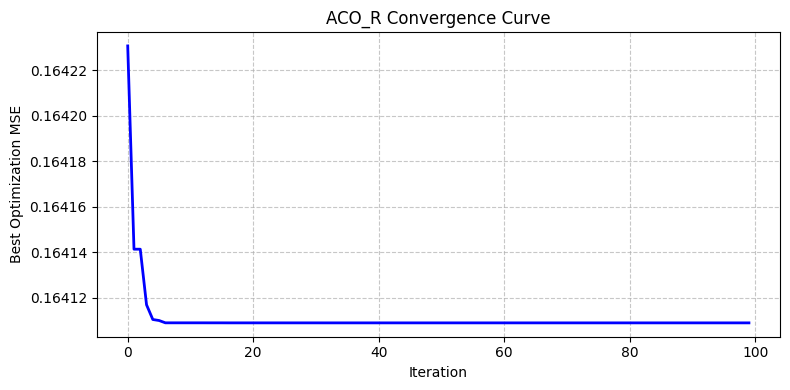

In [29]:
# ==============================================================================
# [Block 4] Swarm Intelligence (Continuous ACO on Optimization Split)
# ==============================================================================
print("\n--- BLOCK 4: ANT COLONY OPTIMIZATION ---")

def map_to_simplex_softmax(w):
    """
    Smooth simplex approximation via softmax.
    Guarantees w_i > 0 and Σw = 1.
    Cannot produce weights of exactly 0.0 (see header note).
    """
    w_stable = w - np.max(w)
    exp_w    = np.exp(w_stable)
    return exp_w / np.sum(exp_w)

def objective_function(w, P, y):
    w_simplex = map_to_simplex_softmax(w)
    return np.mean((P @ w_simplex - y) ** 2)

def run_acor(P, y, num_models,
             n_ants=40, archive_size=20, iterations=100,
             q=0.1, xi=0.85, seed=42):
    # Isolated Generator — does not contaminate the global numpy random state.
    rng     = np.random.default_rng(seed)
    archive = rng.standard_normal((archive_size, num_models))
    scores  = np.array([objective_function(w, P, y) for w in archive])

    sort_idx        = np.argsort(scores)
    archive, scores = archive[sort_idx], scores[sort_idx]

    ranks     = np.arange(1, archive_size + 1)
    weights   = ((1 / (q * archive_size * np.sqrt(2 * np.pi))) *
                 np.exp(-((ranks - 1) ** 2) / (2 * (q * archive_size) ** 2)))
    sel_probs = weights / np.sum(weights)

    convergence_curve = np.zeros(iterations)

    for iteration in range(iterations):
        new_solutions = np.zeros((n_ants, num_models))
        new_scores    = np.zeros(n_ants)

        for ant in range(n_ants):
            guide_idx      = rng.choice(archive_size, p=sel_probs)
            guide_solution = archive[guide_idx]
            sigma          = (xi * np.sum(np.abs(archive - guide_solution), axis=0)
                              / (archive_size - 1))
            # Stagnation guard: prevents degenerate zero-variance proposals.
            sigma = np.maximum(sigma, 1e-6)

            sampled_w          = rng.normal(loc=guide_solution, scale=sigma)
            new_solutions[ant] = sampled_w
            new_scores[ant]    = objective_function(sampled_w, P, y)

        combined_archive = np.vstack((archive, new_solutions))
        combined_scores  = np.concatenate((scores, new_scores))

        sort_idx        = np.argsort(combined_scores)
        archive         = combined_archive[sort_idx][:archive_size]
        scores          = combined_scores[sort_idx][:archive_size]
        convergence_curve[iteration] = scores[0]

    return archive[0], scores[0], convergence_curve

w_ACO_raw, _, convergence = run_acor(
    P_opt, y_opt_float, num_models=P_opt.shape[1]
)
w_ACO = map_to_simplex_softmax(w_ACO_raw)

mse_ACO_comparable = np.mean((P_opt @ w_ACO - y_opt_float) ** 2)
print(f"Optimization MSE — QP Optimal: {mse_optimal:.6f} | ACO Swarm: {mse_ACO_comparable:.6f}")
print(f"ACO Weights converged. L2 Distance to QP Optimal: "
      f"{np.linalg.norm(w_QP - w_ACO):.6f}")

model_names = list(base_models.keys())
print(f"\nWeight Comparison:")
print(f"  {'Model':<22} {'QP':>8} {'ACO':>8}")
for name, wq, wa in zip(model_names, w_QP, w_ACO):
    print(f"  {name:<22} {wq:>8.4f} {wa:>8.4f}")

# Sub-optimality gap: measures ACO quality against the convex optimum.
gap = ((mse_ACO_comparable - mse_optimal) / mse_optimal) * 100
print(f"\nACO Sub-optimality gap vs QP: {gap:.4f}%")

# Convergence visualization (required deliverable per resource.md Block 4.2).
print(f"\nInitial Swarm MSE: {convergence[0]:.6f} "
      f"→ Final MSE: {convergence[-1]:.6f} "
      f"| Reduction: {(1 - convergence[-1] / convergence[0]) * 100:.1f}%")
plt.figure(figsize=(8, 4))
plt.plot(convergence, color='blue', linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Best Optimization MSE")
plt.title("ACO_R Convergence Curve")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [30]:
# ==============================================================================
# [Block 5] Clean Threshold Calibration (isolated Calibration Set)
# ==============================================================================
print("\n--- BLOCK 5: DECISION THRESHOLD CALIBRATION ---")

def calibrate_threshold(y_true, y_probs):
    """Find the threshold that maximises F1 on the provided set."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    # Drop the last coordinate (precision=1, recall=0) — no threshold exists for it.
    precisions, recalls = precisions[:-1], recalls[:-1]
    f1_scores = np.divide(
        2 * (precisions * recalls), (precisions + recalls),
        out=np.zeros_like(precisions),
        where=(precisions + recalls) != 0
    )
    optimal_idx = np.argmax(f1_scores)
    return thresholds[optimal_idx], f1_scores[optimal_idx]

w_equal = np.array([1/3, 1/3, 1/3])

# All thresholds calibrated strictly on P_calib — never seen by the weight optimizers.
t_ACO,   f1_ACO_cal   = calibrate_threshold(y_calib, P_calib @ w_ACO)
t_QP,    f1_QP_cal    = calibrate_threshold(y_calib, P_calib @ w_QP)
t_equal, f1_equal_cal = calibrate_threshold(y_calib, P_calib @ w_equal)

print(f"Calibrated ACO Boundary   (t*): {t_ACO:.4f}   (Calib F1: {f1_ACO_cal:.4f})")
print(f"Calibrated QP Boundary    (t*): {t_QP:.4f}   (Calib F1: {f1_QP_cal:.4f})")
print(f"Calibrated Equal Boundary (t*): {t_equal:.4f}   (Calib F1: {f1_equal_cal:.4f})")


--- BLOCK 5: DECISION THRESHOLD CALIBRATION ---
Calibrated ACO Boundary   (t*): 0.2515   (Calib F1: 0.6023)
Calibrated QP Boundary    (t*): 0.2515   (Calib F1: 0.6023)
Calibrated Equal Boundary (t*): 0.3136   (Calib F1: 0.6093)


In [31]:
# ==============================================================================
# [Block 6] Soft Computing (Neuro-Fuzzy Regressor)
# ==============================================================================
print("\n--- BLOCK 6: ANFIS (NEURO-FUZZY) MAPPING ---")

def inv_sigmoid(y, min_val, max_val):
    """Inverse of the bounded sigmoid. Safe for scalars and arrays."""
    p = (y - min_val) / (max_val - min_val)
    return np.log(p / (1 - p))


class GaussianMF(nn.Module):
    """
    Gaussian membership functions with sigmoid reparameterization.
    Centers are analytically bounded to (min_c, max_c).
    Sigmas  are analytically bounded to (min_s, max_s).
    Eliminates post-hoc clamping, which conflicts with Adam's momentum
    buffers and destabilizes training near constraint boundaries.
    """
    def __init__(self, centers, sigmas):
        super().__init__()
        self.min_c, self.max_c = 0.0, 1.0
        self.min_s, self.max_s = 0.05, 0.3

        raw_centers = []
        for c in centers:
            if not (self.min_c < c < self.max_c):
                raise ValueError(
                    f"Initial center {c} must be strictly inside "
                    f"({self.min_c}, {self.max_c})"
                )
            raw_centers.append(float(inv_sigmoid(c, self.min_c, self.max_c)))
        self._raw_centers = nn.Parameter(
            torch.tensor(raw_centers, dtype=torch.float32)
        )

        raw_sigmas = []
        for s in sigmas:
            if not (self.min_s < s < self.max_s):
                raise ValueError(
                    f"Initial sigma {s} must be strictly inside "
                    f"({self.min_s}, {self.max_s})"
                )
            raw_sigmas.append(float(inv_sigmoid(s, self.min_s, self.max_s)))
        self._raw_sigmas = nn.Parameter(
            torch.tensor(raw_sigmas, dtype=torch.float32)
        )

    @property
    def centers(self):
        return (self.min_c
                + (self.max_c - self.min_c) * torch.sigmoid(self._raw_centers))

    @property
    def sigmas(self):
        return (self.min_s
                + (self.max_s - self.min_s) * torch.sigmoid(self._raw_sigmas))

    def forward(self, x):
        return torch.exp(-0.5 * ((x - self.centers) / self.sigmas) ** 2)


class ANFIS1D(nn.Module):
    """
    First-Order Takagi-Sugeno Neuro-Fuzzy Regressor.
    Academic disclaimer: bypasses Jang's (1993) two-pass hybrid learning
    (LSE for consequents + GD for premises) in favour of a unified Adam
    optimizer for simultaneous parameter updates.
    """
    def __init__(self):
        super().__init__()
        self.fuzzify = GaussianMF([0.1, 0.5, 0.9], [0.2, 0.2, 0.2])
        self.a = nn.Parameter(torch.tensor([0.0, 0.5, 1.0], dtype=torch.float32))
        self.b = nn.Parameter(torch.tensor([0.0, 0.0, 0.0], dtype=torch.float32))

    def forward(self, x):
        w      = self.fuzzify(x)
        w_norm = w / (torch.sum(w, dim=1, keepdim=True) + 1e-8)
        f      = x * self.a + self.b
        return torch.sum(w_norm * f, dim=1)


# Recombine both OOF splits to train ANFIS on all available training predictions.
# w_ACO was fitted only on P_opt, so applying it to P_calib rows is a valid
# out-of-sample operation — no leakage into ANFIS training.
oof_preds_ACO_full = oof_P_train @ w_ACO
X_anfis_tensor = torch.tensor(oof_preds_ACO_full, dtype=torch.float32).view(-1, 1)
y_anfis_tensor = torch.tensor(y_train_array.astype(float), dtype=torch.float32)

# Guarantee reproducible ANFIS initialization across machines and PyTorch versions.
torch.manual_seed(42)
anfis_model = ANFIS1D()
optimizer   = optim.Adam(anfis_model.parameters(), lr=0.01)

# Explicitly declare training mode. Required for correctness if the architecture
# is ever expanded with Dropout or BatchNorm layers.
anfis_model.train()
for epoch in range(500):
    optimizer.zero_grad()
    loss = nn.MSELoss()(anfis_model(X_anfis_tensor), y_anfis_tensor)
    loss.backward()
    optimizer.step()
    # No manual clamping needed — sigmoid reparameterization enforces all bounds.

centers = anfis_model.fuzzify.centers.detach().numpy()
sigmas  = anfis_model.fuzzify.sigmas.detach().numpy()
print("Fuzzy MFs Optimized:")
print(f"  Rule 1: c={centers[0]:.4f}, s={sigmas[0]:.4f} | "
      f"Rule 2: c={centers[1]:.4f}, s={sigmas[1]:.4f} | "
      f"Rule 3: c={centers[2]:.4f}, s={sigmas[2]:.4f}")


--- BLOCK 6: ANFIS (NEURO-FUZZY) MAPPING ---
Fuzzy MFs Optimized:
  Rule 1: c=0.1095, s=0.2067 | Rule 2: c=0.4278, s=0.2161 | Rule 3: c=0.9045, s=0.2034


In [32]:

# ==============================================================================
# [Block 7] Comprehensive Domain Evaluation on Untouched Test Set
# ==============================================================================
print("\n" + "=" * 70)
print("FINAL PIPELINE EVALUATION (TEST SET N=200)")
print("=" * 70)

P_test = np.zeros((X_test.shape[0], len(base_models)))
print("Base Model Independent Test ROC-AUCs:")
for i, (name, model_pipeline) in enumerate(base_models.items()):
    P_test[:, i] = model_pipeline.predict_proba(X_test)[:, 1]
    print(f"  {name:<22}: {roc_auc_score(y_test_array, P_test[:, i]):.4f}")
print("-" * 70)

preds_ACO   = P_test @ w_ACO
preds_QP    = P_test @ w_QP
preds_equal = P_test @ w_equal

# Apply each ensemble's independently calibrated threshold.
binary_ACO   = (preds_ACO   >= t_ACO).astype(int)
binary_QP    = (preds_QP    >= t_QP).astype(int)
binary_equal = (preds_equal >= t_equal).astype(int)

def calculate_expected_cost(y_true, y_pred):
    """
    German Credit asymmetric cost matrix:
      False Negative (lending to a defaulter): cost = 5
      False Positive (rejecting a good customer): cost = 1
    """
    cm = confusion_matrix(y_true, y_pred)
    return (cm[1, 0] * 5) + (cm[0, 1] * 1)

print(f"{'Metric':<14} | {'Equal Avg':<15} | {'QP Optimal':<15} | {'ACO Swarm':<15}")
print("-" * 70)
print(f"{'ROC-AUC':<14} | "
      f"{roc_auc_score(y_test_array, preds_equal):<15.4f} | "
      f"{roc_auc_score(y_test_array, preds_QP):<15.4f} | "
      f"{roc_auc_score(y_test_array, preds_ACO):<15.4f}")
print(f"{'F1-Score':<14} | "
      f"{f1_score(y_test_array, binary_equal):<15.4f} | "
      f"{f1_score(y_test_array, binary_QP):<15.4f} | "
      f"{f1_score(y_test_array, binary_ACO):<15.4f}")
print(f"{'Precision':<14} | "
      f"{precision_score(y_test_array, binary_equal):<15.4f} | "
      f"{precision_score(y_test_array, binary_QP):<15.4f} | "
      f"{precision_score(y_test_array, binary_ACO):<15.4f}")
print(f"{'Recall':<14} | "
      f"{recall_score(y_test_array, binary_equal):<15.4f} | "
      f"{recall_score(y_test_array, binary_QP):<15.4f} | "
      f"{recall_score(y_test_array, binary_ACO):<15.4f}")
print(f"{'Expected Cost':<14} | "
      f"{calculate_expected_cost(y_test_array, binary_equal):<15} | "
      f"{calculate_expected_cost(y_test_array, binary_QP):<15} | "
      f"{calculate_expected_cost(y_test_array, binary_ACO):<15}")

cm_ACO = confusion_matrix(y_test_array, binary_ACO)
print(f"\nSwarm Confusion Matrix (t* = {t_ACO:.4f}):")
print(f"  TN: {cm_ACO[0, 0]:<4} FP: {cm_ACO[0, 1]}")
print(f"  FN: {cm_ACO[1, 0]:<4} TP: {cm_ACO[1, 1]}")

# ------------------------------------------------------------------
# ANFIS Linguistic Interpretation
# ------------------------------------------------------------------
# Principled label mapping: determine which Gaussian MF fires most
# strongly for each test input (INPUT space), then assign the
# linguistic label corresponding to that rule's learned center
# position. This avoids comparing Sugeno output (OUTPUT space)
# directly against MF centers (INPUT space).
# ------------------------------------------------------------------
test_probs_tensor = torch.tensor(preds_ACO, dtype=torch.float32).view(-1, 1)

# Explicitly declare eval mode before inference — disables training-time
# stochastic layers (Dropout, BatchNorm) and locks the computation graph.
anfis_model.eval()
with torch.no_grad():
    firing_strengths  = anfis_model.fuzzify(test_probs_tensor)
    w_norm            = firing_strengths / (
        firing_strengths.sum(dim=1, keepdim=True) + 1e-8)
    dominant_rule_idx = w_norm.argmax(dim=1).numpy()

    # Decomposed forward pass — avoids a redundant second fuzzify() call.
    f             = test_probs_tensor * anfis_model.a + anfis_model.b
    anfis_outputs = (w_norm * f).sum(dim=1).numpy()

# Inverse permutation: maps rule index → linguistic rank (Low/Med/High)
# correctly even if centers reorder during gradient-based training.
sorted_idx    = np.argsort(centers)
rank_of_rule  = np.argsort(sorted_idx)
final_risk_labels = np.array(
    ["Low Risk", "Medium Risk", "High Risk"])[rank_of_rule[dominant_rule_idx]]

# Domain validation: of samples the ensemble flags as defaults,
# what proportion does ANFIS independently classify as High Risk?
aco_predicted_defaults = (binary_ACO == 1)
if aco_predicted_defaults.sum() > 0:
    labels_on_defaults  = final_risk_labels[aco_predicted_defaults]
    high_risk_alignment = np.mean(labels_on_defaults == "High Risk") * 100
    print(f"\nDomain Validation: {high_risk_alignment:.1f}% of ensemble-predicted "
          f"defaults independently mapped to linguistic 'High Risk' by ANFIS.")

print("\nSample Output Integration (First 5 profiles):")
results_df = pd.DataFrame({
    'True Label':       y_test_array[:5],
    'ACO Prob':         np.round(preds_ACO[:5], 4),
    'ANFIS Output':     np.round(anfis_outputs[:5], 4),
    'Linguistic Class': final_risk_labels[:5]
})
print(results_df.to_string(index=False))


FINAL PIPELINE EVALUATION (TEST SET N=200)
Base Model Independent Test ROC-AUCs:
  Random_Forest         : 0.7982
  SVM                   : 0.8280
  MLP                   : 0.8080
----------------------------------------------------------------------
Metric         | Equal Avg       | QP Optimal      | ACO Swarm      
----------------------------------------------------------------------
ROC-AUC        | 0.8254          | 0.8196          | 0.8198         
F1-Score       | 0.6389          | 0.6243          | 0.6243         
Precision      | 0.5476          | 0.4779          | 0.4779         
Recall         | 0.7667          | 0.9000          | 0.9000         
Expected Cost  | 108             | 89              | 89             

Swarm Confusion Matrix (t* = 0.2515):
  TN: 81   FP: 59
  FN: 6    TP: 54

Domain Validation: 35.4% of ensemble-predicted defaults independently mapped to linguistic 'High Risk' by ANFIS.

Sample Output Integration (First 5 profiles):
 True Label  ACO Prob  ANFI